# Identification
Please indicate your name and parcours

#### Student: Arafat ISLAM
#### Parcours: BIMA (IMA)


# Practical works 9 & 10: Face recognition by Eigenfaces method


**The objective of this practical work is to study the properties of the Eigenfaces face recognition method.**

We propose to develop a system capable of:
- identify a face from a database of faces 
- determine whether an image contains a face present in the database
- to decide whether an image represents a face or not

Tools developed in this practical work will be applied to the Yale Faces Database.

## General principle

The problem of face recognition is defined as follows: given a face image, one wishes to determine the identity of the corresponding person.
To this end, it is necessary to have reference images, in the form of a database of faces of all persons known by the system. 
Each face is associated with a vector of characteristics. 
These characteristics are supposed to be invariant for the same person, and different from one person to another one. 
Face recognition then consists of comparing the vector of characteristics of the face to be recognized with those of each of the faces of the database. 
This makes it possible to find the person in the database having the most similar face.

There are several types of methods, distinguished by the type of characteristics used, see _S.A. Sirohey, C.L. Wilson, and R. Chellappa. Human and machine recognition of faces: A survey. Proceedings of the IEEE, 83(5), 1995_ for a state of the art:

- The approaches by face models proceed to a biometric analysis of faces. Pertinent biometrics are the distance between the eyes, length of the nose, and shape of the chin...
- Image-based approaches, by contrast, directly compare faces, considering them as images, for which measures of pre-attentive similarities (without a priori model) are defined.
- Hybrid approaches use the notions of similarity between images, but add a priori knowledge about the structure of a face.

![principe.png](./figs/Figure_1.png)
<center>Figure 1: General Principle of a Face Recognition System</center>

## Analysis by Eigenfaces

Face recognition by Eigenfaces is an image-based approach. 
Each face image is considered as a vector in a space having as many dimensions as the number of pixels in the image. 
The image characteristics are extracted by a method of dimensionality reduction based on principal component analysis (PCA). 
This approach was originally proposed in 1991, see Mr. Turk and A. Pentland. Eigenfaces for recognition. J. Cognitive Neuroscience, 3(1) :71-86, 1991_.

In the following, we will use the italic notation to designate scalars ($m, K,\dots$) and vectors ($x, u$), and boldface  for the matrices ($\mathbf X, \mathbf X_c, \mathbf W, \dots$).

A face image is noted $x$ and represented as a vector of $d$ components. $x[i] (i=0,\cdots,d-1)$ is the pixel number $i$ of this image. A set of faces form a cloud of points in the space $\mathbb{R}^d$. 
The database is divided into two sets: the *training* or *reference* set, used to learn the faces, and the *test* set, used to test the method. 
Faces of the training set are denoted by $x_k^{train}$ $(k=0,\cdots,N_{train}-1)$ and faces of the test set are denoted by $x_k^{test}$ $(k=0,\cdots,N_{test}-1) (k=0,\cdots,N_{test}-1)$.

We note $x_{average}$ the average of the reference faces, or average face. 
The principle of the Eigenfaces method is to model the difference of any face in relation to this average face by a linear combination of a limited number of images $u_h$, called Eigenfaces. 
One image of face $x \in \mathbb{R}^d$ is thus expressed as the average face to which is added a linear combination of eigenfaces:

$$x = x_{average} + \sum_h a_h u_h + \varepsilon$$

where $a_h$ represents the weight of *the eigenface* of index $h$ in the face $x$, and $\varepsilon$ represents the error between $x$ and its approximation by eigenfaces (the error is due to the truncation of the basis of eigenvectors). 
Coefficients $a_h$ play a very important role for face recognition, because they correspond to the face coordinates $x$ in the face subspace.

The Eigenfaces method is based on the fact that the number of eigenfaces is much smaller than the total size of the space, which is called dimensionality reduction. In other words, the basis of eigenfaces is truncated, keeping only the vectors coding for the most significant information.
The images are therefore analyzed in a sub-space of reduced dimensions, which represents more specifically faces, among all possible types of images.

The average face is always the same for a fixed reference database, each face is examined after subtraction of the average face.

## Face database

We use the Yale Faces image database, http://cvc.cs.yale.edu/cvc/projects/yalefaces/yalefaces.html.
In this database, all the faces have been preprocessed, in order to resize and crop them to the size $64\times64$ pixels, so the images can be compared pixel per pixel.


This database contains 120 greyscale images, representing the faces of 15 people. There are 8 images per person, each corresponding to a category of images varying according to the following criteria (see Figure 2):
- variation of facial expression: normal, sad, sleepy, surprised,
    wink, happy
- variation of accessories: glasses, noglasses,

![database.png](./figs/Figure_2.png)
<center>Figure 2: Illustration of the shooting categories</center>

The database is divided into two groups: the reference group will be used as a training set, and the other group as a test set: 
- the reference base contains $n$ images, each with a number of pixels $d=n_l\times n_c$. There are $6$ images per person in the training database, so $n=6\times15=90$. Each image is $64\times64$, hence $d=4096$, 
- the test base contains $2$ images per person so a total of 30 images. Each image is again $64\times64$.

In the following, we always manipulate face images in the form of vectors, and a set of faces in the form of a matrix where each column is a face. 
As we use Numpy, the images are stored in a multi-dimensional array of reals (double). 
This array is viewed as a matrix $\mathbf X$ of size $d\times n$: $$\mathbf X= \left[ x_0, ..., x_{n-1}\right]$$.

The matrix $\mathbf X$ is split into $\mathbf X^{train}$ and $\mathbf X^{test}$ of size $d\times N_{train}$ and $d\times N_{test}$, respectively.

# Exercise 1: loading the database, display, and centering of faces

Vectors $id$ and $cat$ give information about the images: $id[k]$ and $cat[k]$ are respectively the identification (an index) and the category of face $k$. These vectors are available for the reference and the test bases and will be useful in the following.

To load the database, we simply have to read the Matlab file `YaleFaces.mat` provided with this notebook: it provides the matrices and vectors $\mathbf X^{train}, \mathbf X^{test}, id^{train}, id^{test}, cat^{train}, cat^{test}$.

The following code loads the database and creates the various matrices and vectors: 

In [2]:
##### Useful libraries
import numpy.linalg
import numpy as np
import matplotlib.pyplot as plt

## Loading YaleFaces database
import scipy.io

yaleFaces = scipy.io.loadmat('./YaleFaces.mat')

# The training set (90 faces)
X_train = yaleFaces['X_train']
cat_train = yaleFaces['cat_train'][0]
id_train = yaleFaces['id_train'][0]-1

# The test set (30 faces)
X_test = yaleFaces['X_test']
cat_test = yaleFaces['cat_test'][0]
id_test = yaleFaces['id_test'][0]-1

# Additional images that don't contain faces 
X_noface = yaleFaces['X_noface']

1.  Write a function that computes the average face $x_{moy}$. \
    Tip: use `mean` function from Numpy.

In [16]:
def meanFaces(X):
    """ Array[d,n] -> Vector[d] """
    # each column of X is one face
    # so I need to taake the mean over all columns
    x_mean = np.mean(X, axis=1)

    return x_mean


I have defined the function. In this function it computes the average face from the database. at First I computeed the average face of the training database. Each face is represented as a vector. And I got the the average face is by taking the mean of all face vectors pixel by pixel.

training faces size:  (4096, 90)
average face:  (4096,)


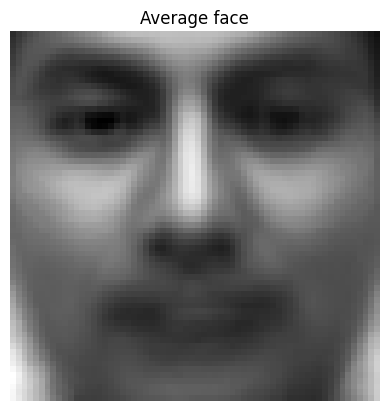

Images from the database: 


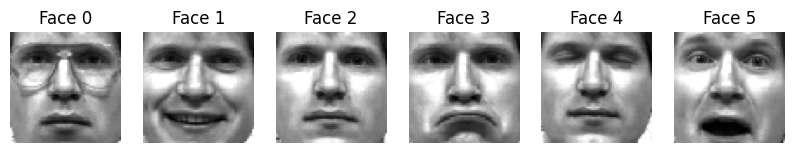

In [20]:
x_mean = meanFaces(X_train)

print("training faces size: ", X_train.shape) 
print("average face: ", x_mean.shape)    

plt.figure()
plt.imshow(x_mean.reshape(64, 64).T, cmap='gray')
plt.title("Average face")
plt.axis('off')
plt.show()

# I have used .T to transpose the images in visualization. because initially it was 90 degree rotated to the right
# I want to see some picture from the database.
print("Images from the database: ")
plt.figure(figsize=(10, 4))
for i in range(6):
    plt.subplot(1, 6, i+1)
    plt.imshow(X_train[:, i].reshape(64, 64).T, cmap='gray')
    plt.title(f"Face {i}")
    plt.axis('off')
plt.show()



2.  Write a function that centers the faces. \
    Recall: center means subtract the average face.

In [18]:
def centeredFaces(X):
    """ Array[d,n]*Vector[d] -> Array[d,n] """
    # need to compute the average face
    x_mean = meanFaces(X)

    # now subtract the average face from each face to get center
    X_centered = X - x_mean[:, np.newaxis]

    return X_centered


In [19]:
test = centeredFaces(X_train)
print(test.shape) 


(4096, 90)


I have defined the function that do centers the faces by subtracting the average face. I have tested the function and printed the shape to see if it is working correctly.

3. Write a function `deflat()` that takes as argument a face, represented as a vector of 4096 elements, and returns an image of size $64\times64$. \
   Important: the Yale Faces database has been created in Matlab, for which the matrices are organized column by column. It may be useful to transpose the matrix.


In [21]:
def deflat(V):
    """" Vector[4096] -> Array[64,64] """
    
    
    # at first need to reshape the vector into a 64x64 image
    # the I need to do transpose because the data comes from Matlab column wise order
    I = V.reshape(64, 64).T

    return I


I have defined the function to converts a face vector back into a 2D image. Faces are stored as vectors of length 4096. To visualize a face I reshape the vector into a 64×64 image. because the database was created in Matlab I transpose the image to correct its orientation

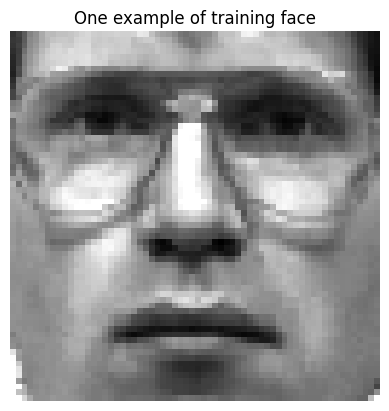

In [23]:
plt.figure()
plt.imshow(deflat(X_train[:, 0]), cmap='gray')
plt.title("One example of training face")
plt.axis('off')
plt.show()


4. Display the average face, as well as a few faces with the associated centered faces. Here is an example of the expected result:
![Figure_3.png](./figs/Figure_3.png)
<center>Figure 3: average face and centering of the database</center>

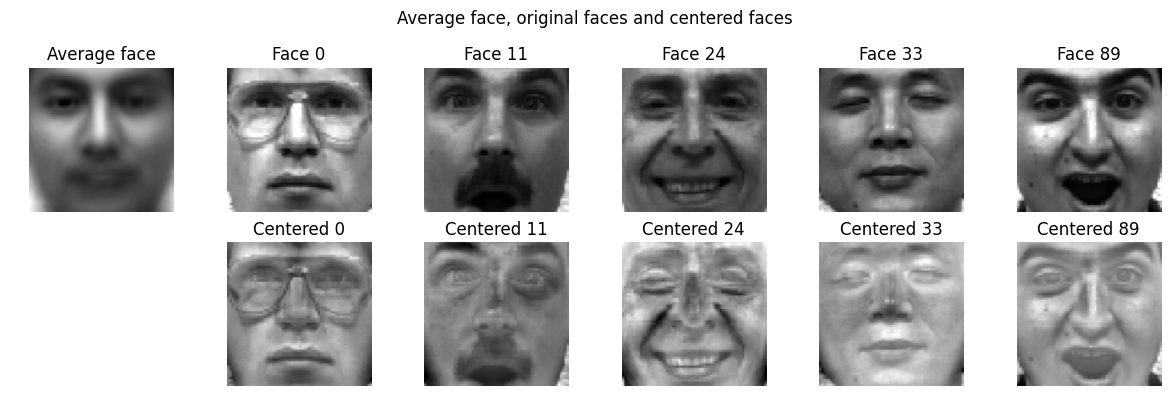

In [27]:
# first need to calculate the average face
x_mean = meanFaces(X_train)
# then now need to center training faces
Xc_train = centeredFaces(X_train)
# i have randomly choose 5 faces to display
idx_faces = [0, 11, 24, 33, 89]

plt.figure(figsize=(12, 4))

#i'm using subplot to visualize the images
plt.subplot(2, 6, 1)
plt.imshow(deflat(x_mean), cmap='gray')
plt.title("Average face")
plt.axis('off')

plt.subplot(2, 6, 7)
plt.axis('off')

# now first rom im visualizing the rriginal faces images
for i, idx in enumerate(idx_faces):
    plt.subplot(2, 6, i + 2)
    plt.imshow(deflat(X_train[:, idx]), cmap='gray')
    plt.title(f"Face {idx}")
    plt.axis('off')

#in 2nd row im visualizing centered faces images
for i, idx in enumerate(idx_faces):
    plt.subplot(2, 6, i + 8)
    plt.imshow(deflat(Xc_train[:, idx]), cmap='gray')
    plt.title(f"Centered {idx}")
    plt.axis('off')

plt.suptitle("Average face, original faces and centered faces")
plt.tight_layout()
plt.show()


I first visualized the average face image. It looks blurred because it represents the mean of all training faces. That means is contains only the common facial structure. Then I visualized five original faces from the training set I selected randomly. In 2nr row of each original face image I have visualized its centered version of image. I got this by subtracting the average face. In the centered faces the global face shape is removed. the differences like face expressions, glasses, mouth shape, teeth is more visible but less contrast comparing the original iamge. 

# Exercise 2: Computation of Eigenfaces (PCA)


The method developed by Turk and Pentland defines the eigenfaces as the main axes obtained by carrying out a principal component analysis (PCA) of the vectors associated with the reference faces. 
**The eigenfaces are thus the eigenvectors of the covariance matrix $\mathbf X_c\mathbf X_c^\top$**, of size $d\times d$ , where the matrix $\mathbf X_c$ of the same size as $\mathbf X$ represents all the centered faces:
$$\mathbf X_c= \left[ x_0-x_{moy}, \cdots x_{n-1}-x_{moy}\right]$$
Each line of $\mathbf X_c$ corresponds to a pixel $p$, each column of $\mathbf X_c$ corresponds to a reference face of index $k$.

Rather than using eigenvalue decomposition, we will use singular value decomposition (SVD). 
The SVD decomposes the matrix $\mathbf X_c$ of size $d\times n$ into 3 matrices $\mathbf U$, $\mathbf S$, $\mathbf V$ such as :

$$\mathbf X_c=\mathbf U \mathbf S\mathbf V^\top$$

where $\mathbf U$ and $\mathbf V$ are orthogonal matrices ($\mathbf U \mathbf U^\top=\mathbf U^\top \mathbf U=\mathbf I_d^d$ and $\mathbf V \mathbf V^\top=\mathbf V^\top \mathbf V=\mathbf I_d^n$) of respective sizes $d\times d$ and $n\times n$, and $\mathbf S$ is a matrix of size $d\times n$ with null elements everywhere except on the main diagonal.

This decomposition has the following properties:
- the columns of $\mathbf V$ are the eigenvectors of $\mathbf X_c^\top\mathbf X_c$, 
- the columns of $\mathbf U$ are the eigenvectors of $\mathbf X_c\mathbf X_c^\top$,
- the matrix $\mathbf S$ is diagonal. The diagonal represents the singular values of $\mathbf X_c$, equal to the square roots of the eigenvalues $\lambda_k$ of $\mathbf X_c^\top\mathbf X_c$ and
    $\mathbf X_c\mathbf X_c^\top$. 

With Numpy, the SVD can be calculated by this way:

`U, S, V = numpy.linalg.svd(Xc)`

In our case, $n<d$, and the eigenvalues $\lambda_k$ of $\mathbf X_c\mathbf X_c^\top$ are therefore all null for $k>n$.
We will not need the associated eigenvectors $k>n$. 
The `svd` function has a fast mode, which calculates only the eigenvectors corresponding to the columns of the matrix passed as argument:

`U, S, V = svd(Xc, full_matrices=False)`


This command returns the matrices $\mathbf U$ and $\mathbf V$, of size $d\times n$ and $n\times n$, and the matrix $\mathbf U$ matrix has been truncated, only the first $n$ columns are retained:
$$\mathbf U= \left[ u_1, \cdots, u_n\right]$$
Finally `S` is a vector of size $n$ and represents the diagonal matrix $\mathbf S$.

1. Write a function `eigenfaces(Xc)` which returns a t-uple consisting of the $\mathbf U$ matrix of eigenfaces, computed from a centered database $\mathbf X_c$, and the table of associated eigenvalues.
        

In [57]:
def eigenfaces(Xc):
    """ Array[d,n] -> Array[d,n]*Vector[n] """
    # applying SVD on the centered face matrix
    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)

    # U has the eigenfaces one eigenface per column and i know that the eigenvalues are the squares of the singular values
    eigenvalues = S**2

    return U, eigenvalues


In [30]:
# testing
Xc = centeredFaces(X_train)
U, eigvals = eigenfaces(Xc)

print(U.shape)        
print(eigvals.shape) 


(4096, 90)
(90,)


To compute the eigenfaces I have applied Singular Value Decomposition (SVD) to the centered face matrix. The columns of the matrix U correspond to the eigenfaces. and I got the associated eigenvalues  by squaring the singular values. These eigenfaces represent the main directions of variation in the face database.

2. Use this function to calculate $\mathbf U$ and $\mathbf S$. Normalize then the eigenvalues so that their sum is equal to 1.


In [31]:
# centering the training faces
Xc_train = centeredFaces(X_train)

# now computing eigenfaces and eigenvalues
U, eigenvalues = eigenfaces(Xc_train)

#now normalizing eigenvalues so that their sum is equal to 1
eigenvalues_norm = eigenvalues / np.sum(eigenvalues)




In [32]:
# test check
print("Sum of normalized eigenvalues:", np.sum(eigenvalues_norm))

Sum of normalized eigenvalues: 1.0


I first compute the eigenfaces and the associated eigenvalues using SVD on the centered training database. and then I normalize the eigenvalues by dividing them by their sum so that they represent the proportion of variance explained by each eigenface. I check by printing after normalization the sum of the eigenvalues is equal to 1.

3. Display the average face and the first 15 eigenfaces (see figure 4, use the `plt.subplot()` function).
   and their associated own values. Give your interpretation of the eigenfaces images?

![Figure_4.png](./figs/Figure_4.png)
<center>Figure 4: the 15 first eigenfaces</center>

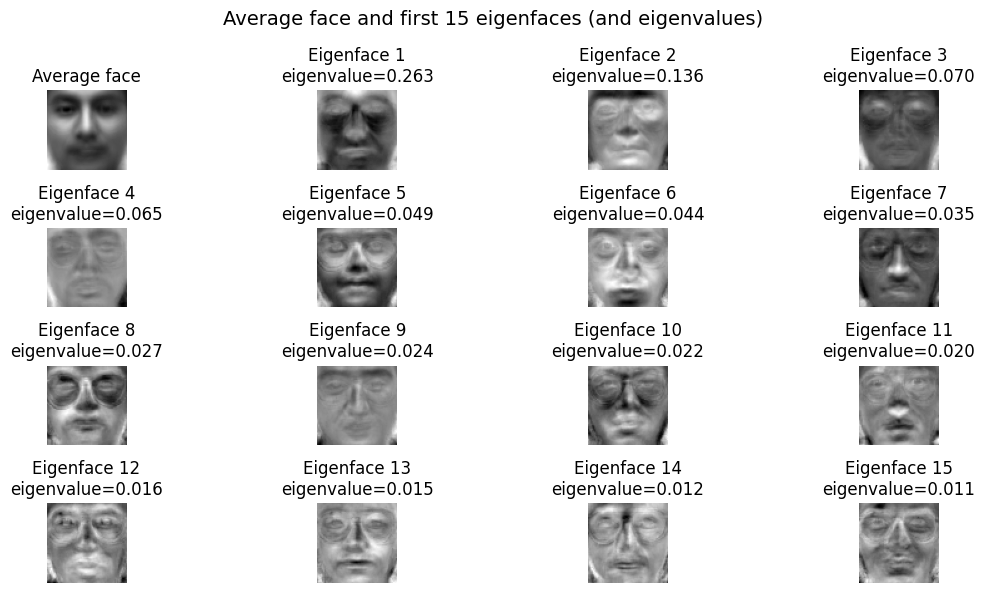

In [35]:
K = 15
# i need to display 15 images


plt.figure(figsize=(12, 6))

# visualizing average face 
plt.subplot(4, 4, 1)
plt.imshow(deflat(x_mean), cmap='gray')
plt.title("Average face")
plt.axis('off')

# now visualizing 15 eigenfaces and with eigenvalues 
for i in range(K):
    plt.subplot(4, 4, i + 2)
    plt.imshow(deflat(U[:, i]), cmap='gray')
    plt.title(f"Eigenface {i+1}\neigenvalue={eigenvalues_norm[i]:.3f}")
    plt.axis('off')

plt.suptitle("Average face and first 15 eigenfaces (and eigenvalues)", fontsize=14)
plt.tight_layout()
plt.show()


In eigenfaces visualization images I see that they do not represent like the real faces. It like patterns of variation between faces in the database like each image is overlay of many images. The first eigenfaces are the most important ones because they have the largest eigenvalues. so it means means they explain most of the differences between faces. i saw that Eigenface 1 blurry, unclear to my eyes but it means taht its captures global information like overall brightness and strong shadows. specially around the eyes and nose. This is correct because illumination changes affect many pixels at the same time. In Eigenface 2, 3 i see more facial structure, more clear like the shape of the nose, eyes, mouth etc. and other eigenfaces  the images become more detailed but also noisier. I think these eigenfaces capture finer variations like facial expressions like open mouth, smiling, surprised face etc. glasses, small differences between each person face. and also the associated eigenvalues also decrease. this means these variations are less important than the global ones. I can say that i understand each eigenface represents a direction of variation in the face database. a face can be reconstructed by combining the average face with a weighted sum of these eigenfaces. The first eigenfaces has the most useful information for recognition but the later other ones mainly capture small details and noise.

4. Plot the curve of the cumulative sum of the normalized eigenvalues (see Figure 5 for the expected result), to see how much variation is captured by the first $K$ eigenfaces. How many eigenfaces are needed to obtain a good reconstruction?    
    
![Figure_5.png](./figs/Figure_5.png)
<center>Figure 5: cumulative sum of eigenvalues</center>

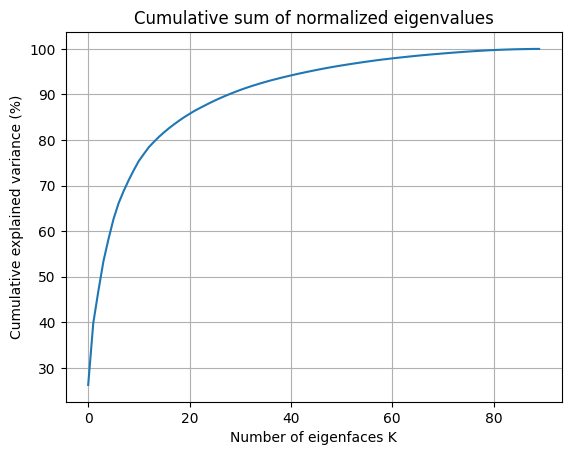

In [41]:
# first I need to compute cumulative sum of normalized eigenvalues
cumulative_variance = np.cumsum(eigenvalues_norm) * 100


plt.figure()
plt.plot(cumulative_variance)
plt.xlabel("Number of eigenfaces K")
plt.ylabel("Cumulative explained variance (%)")
plt.title("Cumulative sum of normalized eigenvalues")
plt.grid(True)
plt.show()


as per as I remember from lecture class is that using fewer eigenfaces reduces dimensionality and noise but still keeping the main facial structures.
From the cumulative variance curve visualization I can see that most of the information is captured by the first eigenfaces. Around 30 to 40 eigenfaces more than 90% of the total variance is already explained. After that the curve increases very slowly. which means additional eigenfaces do not add much information. so that means using about 30 to 40 eigenfaces is enough to get a good reconstruction of the faces.

# Exercise 3: projection in the subspace of faces


In the following, we use a reduced number of eigenfaces/eigenvectors. The vectorial space of faces, $\mathbf W_K$, is spanned by the basis formed with the $K$ first eigenvectors:

$$\mathbf W_K = \left[ u_1, ..., u_K\right]$$

Note that the set of columns of $W_K$ is an orthonormal basis, so $\mathbf W^\top_K\times \mathbf W_K=\mathbf I_d^K$.

The **projection of a face image $x$ in the face subspace** is simply done by subtracting from $x$ the average face and applying the scalar product with each eigenvector. 
This gives the coordinates of the image $x$ in the subspace of faces, which is of dimension $K$.

Each face therefore has several representations:
-   the original image, a vector $x \in \mathbb{R}^d$
-   the coordinates of the projected image $z$ in the basis of eigenfaces,
    $\left\lbrace a_h\right\rbrace$,
    $h \in\left\lbrace 1;K\right\rbrace$ (subspace of faces):
    $$z = \mathbf W_K^\top (x-x_{average})$$
-   its reconstruction in the original space $\mathbb{R}^d$,
    $\tilde{x}$:
    $$\tilde{x} = x_{average} + \sum_h a_h u_h = x_{moy} + \mathbf W_K  z$$

**The reconstruction error is defined** as the distance between a face $x$ and the associated reconstruction $\tilde x$:
$$E^{recons}(x) =\|x-\tilde{x}\|_2  = \sqrt{\sum_{p=1}^d \left( x(p) - \tilde{x}(p)\right) ^2}$$

1. Write a function `projEigenfaces()` which takes as arguments a face, $x$, the average face, $x_{average}$, the subspace of faces $\mathbf W$, the number of eigenfaces $K$, and  computes the coordinates of projected face $z$ in the subspace $\mathbf W_K$ of faces.    

In [42]:
def projEigenface(x, x_mean, W, K):
    """ Vector[d]*Vector[d]*Array[d,n]*int -> Vector[K] """
    # first need to subtract the average face which is centering
    x_centered = x - x_mean

    # now need to keep only the first K eigenfaces whic is subspace W_K
    Wk = W[:, :K]

    # now the projection step here z = W_K^T (x - x_mean)
    z = Wk.T @ x_centered

    return z


inside the function i have first centered the face by subtracting the average face. Then I project it onto the first K eigenfaces by computing the dot product with each eigenface. The result is a vector z of size K. it represents the coordinates of the face in the face subspace.

2.  Write a function `reconstruct()` which takes as arguments a projected face, $z$, the average face, $x_{average}$, and the truncated subspace of face, $W$ and $K$, and computes the coordinate of $x$ in the original space ($\mathbb{R}^n$).    

In [47]:
def reconstruct(z, x_mean, W, K):
    """Vector[K]*Vector[d]*Array[d,n]*int -> Vector[d] """
    # first need to take only the first K eigenfaces
    Wk = W[:, :K]

    # now need to reconstruct the face by using x_mean + WK * z
    x_rec = x_mean + Wk @ z

    return x_rec


Here I in this function I rebuild the face from its coordinates in the eigenfaces space. I multiply the projection vector z by the first K eigenfaces. After that I have added back the average face. This gives an approximation of the original face in the image space.

3.  Write a function  `errorReconstruct()` which computes the recontruction error between $\tilde{x}$ and $x$.

In [48]:
def errorReconstruct(x_r, x):
    """Vector[d]*Vector[d] -> float """
    # at first need to compute the difference between original and reconstructed face
    diff = x - x_r

    # then compute the L2 norm of the difference
    error = np.linalg.norm(diff, 2)

    return error


In this function I wrote it to compute the reconstruction error between original face and reconstructed face. The reconstruction error measures how different the reconstructed face is from the original one. It is calculated using the L2 norm of the difference between the two vectors. 

4.  Write a function `affiche_Reconstruction()` which displays:
    - the original face $x$,
    - the reconstructed faces $x_r$ for various values of $K$ (for instance, $K =$ 5, 10, 25, 50, 90).

In [49]:
def affiche_reconstruction(x, x_moy, W, listK):
    """ Vector[d]*Vector[d]*Array[d,n]*list[int] -> NoneType """
    # total number of images to display is original iamge and the reconstructions so
    n = len(listK) + 1

    plt.figure(figsize=(3*n, 3))

    # now visualizing first Original face images
    plt.subplot(1, n, 1)
    plt.imshow(deflat(x), cmap='gray')
    plt.title("Original face")
    plt.axis('off')

    # now first need to reconstructed faces for different K 
    for i, K in enumerate(listK):
        # using the projEigenface function to project the face into eigenfaces subspace
        z = projEigenface(x, x_moy, W, K)

        # using reconstruct function to reconstruct the face from projection
        x_rec = reconstruct(z, x_moy, W, K)

        # visualizing the reconstructed face images
        plt.subplot(1, n, i + 2)
        plt.imshow(deflat(x_rec), cmap='gray')
        plt.title(f"K = {K}")
        plt.axis('off')

    plt.suptitle("Face reconstruction using Eigenfaces")
    plt.tight_layout()
    plt.show()


I have defined this function to visualize the original face and several reconstructed image. this is done by using different numbers of eigenfaces. 

5.  Test the previous functions by displaying the projection/reconstruction result for several images (from the training and test bases). Figure 6 shows the result of the reconstruction for image 50 of the training base. For image 55 of the training base, what is the reconstruction error for $K=n=90$? Is the image identical to its reconstruction? Same question for image 17 of the test base.

![Figure_6.png](./figs/Figure_6.png)
<center>Figure 6: Example of reconstruction for image number 50</center>

Training image 55 reconstruction error (K=90): 8.47245307921256e-12


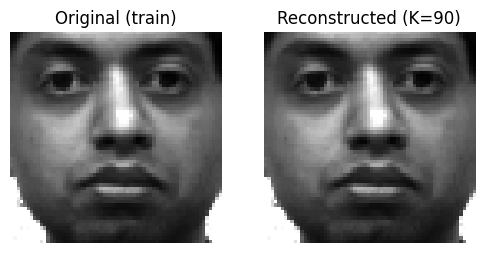

Test image 17 reconstruction error (K=90): 1288.3097091850734


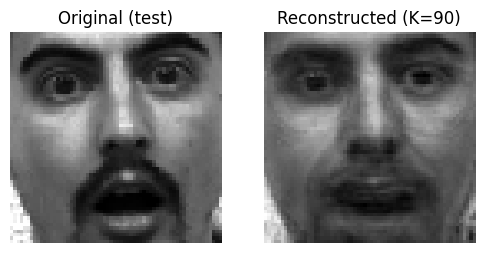

In [55]:
# I want to use all eigenfaces
K = 90  
# image 55 from training base
idx_train = 55 
# image 17 from test base
idx_test = 17   


x_train_img = X_train[:, idx_train]
z_train = projEigenface(x_train_img, x_mean, U, K)
# now reconstruction image
x_train_rec = reconstruct(z_train, x_mean, U, K)
# now calculating the reconstruction error
err_train = errorReconstruct(x_train_rec, x_train_img)
print(f"Training image {idx_train} reconstruction error (K=90):", err_train)

# visualizing the images
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plt.imshow(deflat(x_train_img), cmap='gray')
plt.title("Original (train)")
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(deflat(x_train_rec), cmap='gray')
plt.title("Reconstructed (K=90)")
plt.axis('off')
plt.show()


# now same for testing base
x_test_img = X_test[:, idx_test]
z_test = projEigenface(x_test_img, x_mean, U, K)
x_test_rec = reconstruct(z_test, x_mean, U, K)
err_test = errorReconstruct(x_test_rec, x_test_img)
print(f"Test image {idx_test} reconstruction error (K=90):", err_test)

# now visualizing
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plt.imshow(deflat(x_test_img), cmap='gray')
plt.title("Original (test)")
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(deflat(x_test_rec), cmap='gray')
plt.title("Reconstructed (K=90)")
plt.axis('off')
plt.show()


at first first I tested image 55 from the training set with K=90. The reconstruction error is 8.47245307921256e-12 which is almost zero. When I compare the original image and the reconstructed image they look similar. This is I have expected because the image are in the training set and all 90 eigenfaces were used. Then I also tested image 17 from the test set with K=90. The reconstruction error is much larger 1288.3097091850734 and in visualization the reconstructed face is still similar to the original one but it is not identical some details are blurred and the facial expression is not fully preserved and changed. T think this is because test images were not used to compute the eigenfaces. so they cannot be represented exactly as a linear combination of the training eigenfaces.

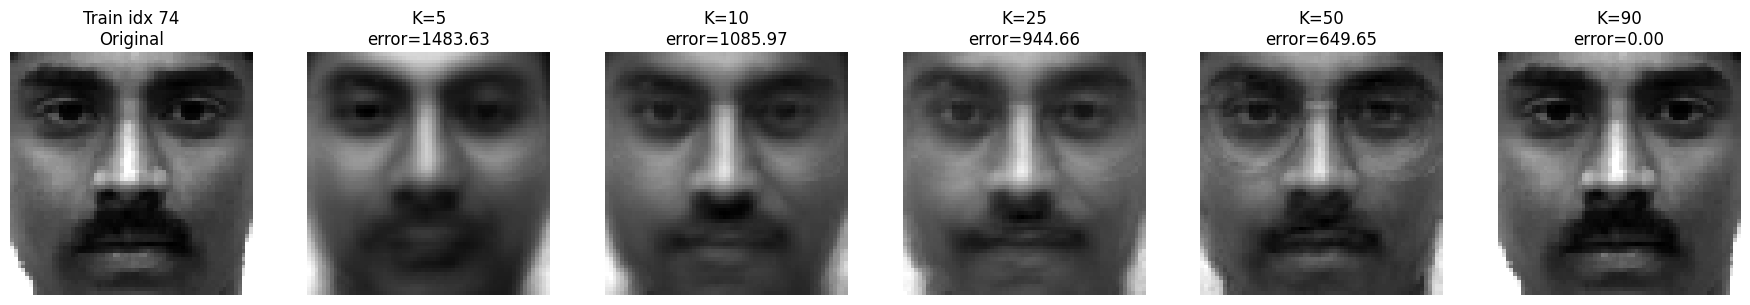

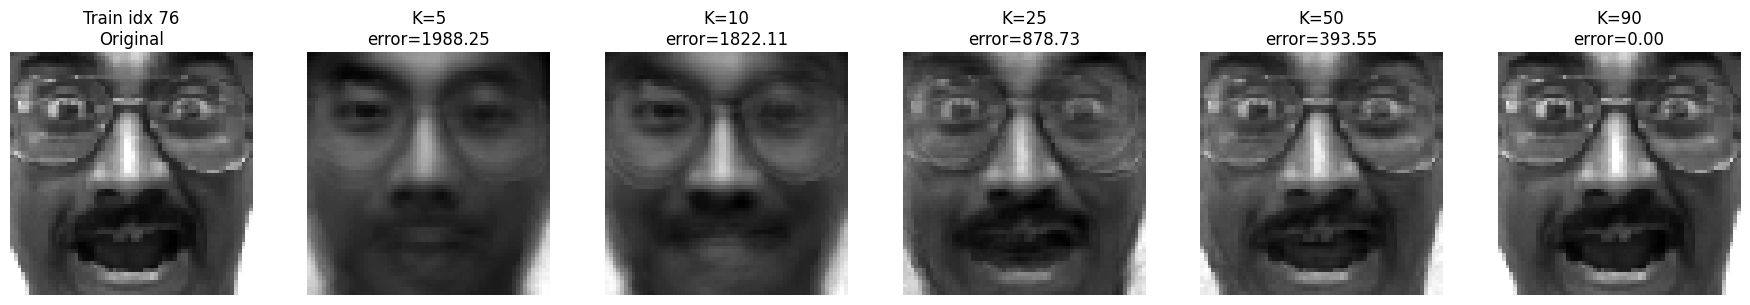

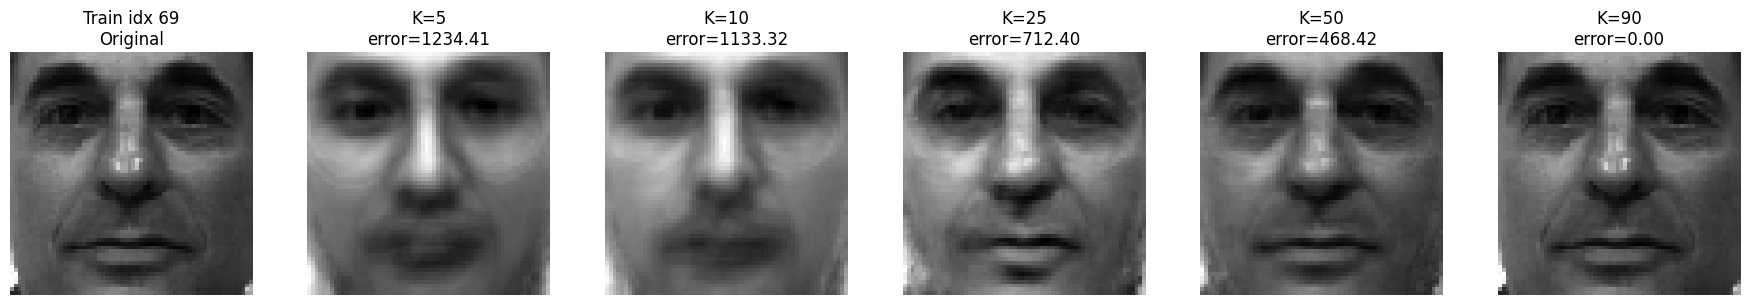

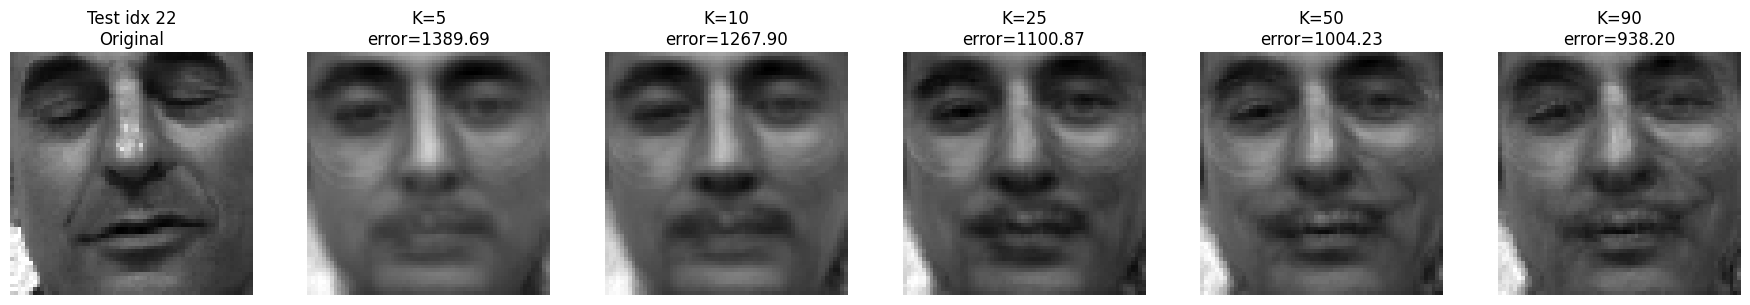

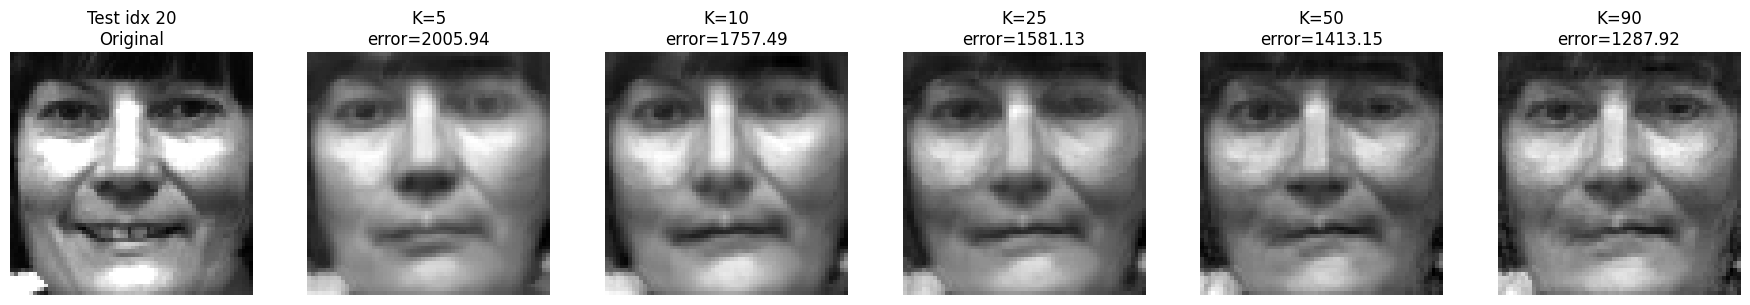

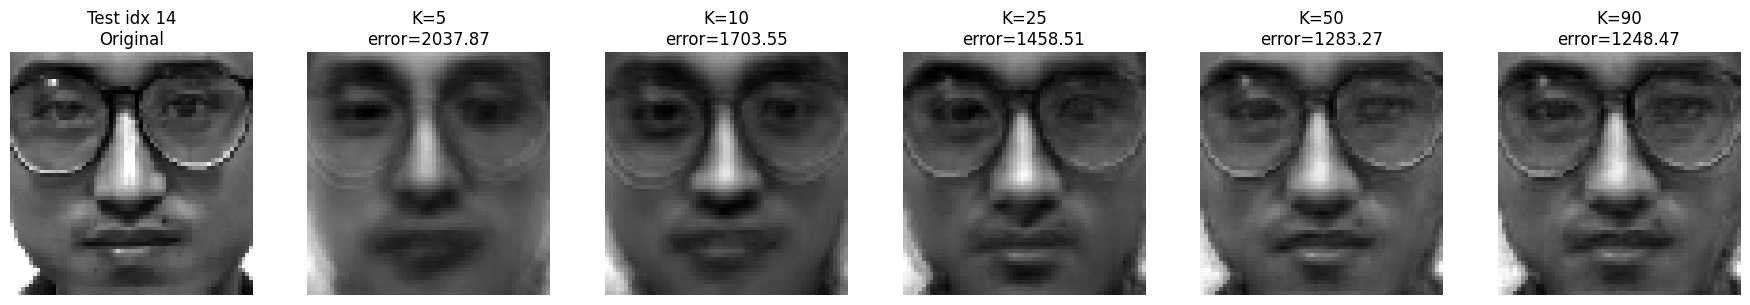

In [54]:
import random

# these are the K values to test
listK = [5, 10, 25, 50, 90]

# randomly choosing 3 images from train and 3 from test set
random_train_idx = random.sample(range(X_train.shape[1]), 3)
random_test_idx  = random.sample(range(X_test.shape[1]), 3)

# writing a function to visualize original image and reconstructions image for different K values with error also
def show_reconstructions_for_one_face(x, title_prefix):
    ncols = 1 + len(listK)  
    plt.figure(figsize=(3*ncols, 3))

    # original image visualization
    plt.subplot(1, ncols, 1)
    plt.imshow(deflat(x), cmap='gray')
    plt.title(f"{title_prefix}\nOriginal")
    plt.axis('off')
    # reconstructions image visualization
    for i, K in enumerate(listK):
        z = projEigenface(x, x_mean, U, K)
        x_rec = reconstruct(z, x_mean, U, K)
        err = errorReconstruct(x_rec, x)

        plt.subplot(1, ncols, i + 2)
        plt.imshow(deflat(x_rec), cmap='gray')
        plt.title(f"K={K}\nerror={err:.2f}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()


#now visualizing 3 random training faces 
for idx in random_train_idx:
    x = X_train[:, idx]
    show_reconstructions_for_one_face(x, f"Train idx {idx}")

# noe visualizing 3 random test faces
for idx in random_test_idx:
    x = X_test[:, idx]
    show_reconstructions_for_one_face(x, f"Test idx {idx}")


I have also tried randomly select 3 from test and 3 from train set. I see when K is small the reconstructionimages is blurry and lacks a lot of details. but when K increases more facial details I can see and the reconstructed face becomes closer to the original image. and when k increased the reconstruction error also decreased. but the reconstruction image of train images are better that train images.

6. Is there a difference between the reconstructions of the faces from the training base and those from the test base? Why?

After visualizing 55 and 17 image i see there is a clear difference between the reconstructions of faces from the training base and those from the test base. the training face reconstruction is almost identical similar to the original image. The reconstruction error is extremely small almost zero and visually there is no noticeable difference. this result i got because in the function the eigenfaces were computed directly from the training images. When i used all K=90 eigenfaces. that means training image can be represented exactly as a linear combination of these eigenfaces. but the test face reconstruction is not identical to the original image. Even though I see the reconstructed image still looks like the same person but it is more blurred and some details like facial expression and textures are lost not in reconstruction image. The reconstruction error is also much larger. This is because test images were not used to build the eigenface space thats why they do not present exactly in that subspace. and using function I wrote before it can only be approximated close to but not similar.

7. __Bonus question__: Plot the evolution of the average error of reconstruction of test faces when $K$ varies from 1 to $N$. Is this evolution consistent with the cumulative sum previously calculated (exercise 2, question 4)?

for  80%, 90%,95% variance the k and test error:
K for 80% variance: 15  and average test error: 1391.001587777283
K for 90% variance: 29  and average test error: 1215.496207166747
K for 95% variance: 45  and average test error: 1130.0049321509964

 for different K cumulative variance and average test error:
for K= 1,cumulative variance=26.26%, average test error=2244.64
for K= 5,cumulative variance=58.25%, average test error=1784.82
for K=10,cumulative variance=73.40%, average test error=1522.54
for K=25,cumulative variance=88.14%, average test error=1247.50
for K=50,cumulative variance=96.19%, average test error=1108.30
for K=90,cumulative variance=100.00%, average test error=1023.02


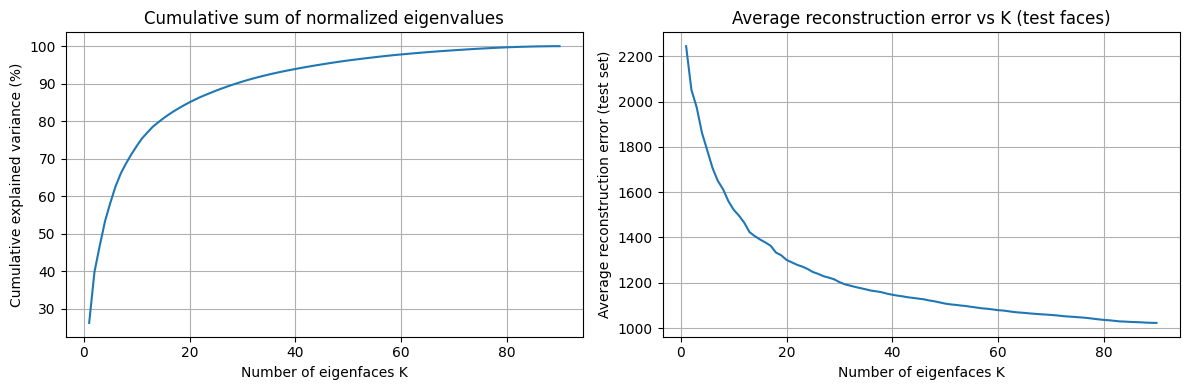

In [61]:
maxK = 90

# first average reconstruction error on TEST set for K=1 to 90
errors_test = []

for K in range(1, maxK + 1):
    err_K = []
    for i in range(X_test.shape[1]):
        x = X_test[:, i]
        z = projEigenface(x, x_mean, U, K)
        x_rec = reconstruct(z, x_mean, U, K)
        err_K.append(errorReconstruct(x_rec, x))
    errors_test.append(np.mean(err_K))

errors_test = np.array(errors_test)

# now calculating cumulative explained variance (%) 
cumulative_variance = np.cumsum(eigenvalues_norm) * 100  

# printing few values to compare
def first_K_for_threshold(th):
    return int(np.argmax(cumulative_variance >= th) + 1)

K80 = first_K_for_threshold(80)
K90 = first_K_for_threshold(90)
K95 = first_K_for_threshold(95)
print("for  80%, 90%,95% variance the k and test error:")
print("K for 80% variance:", K80, " and average test error:", errors_test[K80-1])
print("K for 90% variance:", K90, " and average test error:", errors_test[K90-1])
print("K for 95% variance:", K95, " and average test error:", errors_test[K95-1])

# also print a few fixed K values
print("\n for different K cumulative variance and average test error:")
for K in [1, 5, 10, 25, 50, 90]:
    print(f"for K={K:2d},cumulative variance={cumulative_variance[K-1]:.2f}%, average test error={errors_test[K-1]:.2f}")

# now visualizing both curves using subplots 
plt.figure(figsize=(12, 4))

# this is cumulative variance
plt.subplot(1, 2, 1)
plt.plot(range(1, maxK + 1), cumulative_variance)
plt.xlabel("Number of eigenfaces K")
plt.ylabel("Cumulative explained variance (%)")
plt.title("Cumulative sum of normalized eigenvalues")
plt.grid(True)

# this is average reconstruction error
plt.subplot(1, 2, 2)
plt.plot(range(1, maxK + 1), errors_test)
plt.xlabel("Number of eigenfaces K")
plt.ylabel("Average reconstruction error (test set)")
plt.title("Average reconstruction error vs K (test faces)")
plt.grid(True)

plt.tight_layout()
plt.show()


I have printed and also plotted both the cumulative explained variance and the average reconstruction error curve. It was on the test set as a function of K. I can see in the graph that they are consistent with each other. When K is small only a small part of the variance is captured. for example about 26% for K=1 and the reconstruction error is very high. When K increased the cumulative variance increases quickly like 80% when K=15 and like 90% when K=29.And at the same time the average reconstruction error decreases a lot. After about K=40 to 50 the cumulative variance is already close to 100%.  this means the first eigenfaces has the most of the important information.

# Exercise 4: Face recognition and identification

Each reference face $x_k^{train}$ has an identity associated with it, in the form of a $id^{train}(k)$ number. In this section, we try to identify a face $x^{test}$ from the reference faces.

The simplest method is to compare the projection $z^{test}$ of the test face $x^{test}$ with the projection $z_k^{train}$ of each reference image $x_k^{train}$ (see Figure 7). The dissimilarity between the two projected vectors is quantified by the distance in subspace $E_k(x^{test})$:

$$E_k(x^{test}) =\|z^{test}-z_k^{train}\|_2$$

![Figure_7.png](./figs/Figure_7.png)
<center>Figure 7: Projection of an image $J$ in the subspace of faces and comparison with a reference face $I_k$, in case $K=2$.<center>

This distance is evaluated for each reference face, we can determine the reference face $x_k^{train}$ closest to the test face $x^{test}$. **Its identifier $id^{train}(k)$ then allows for the recognition of the tested face.**


1.  What is the advantage of calculating the distance $E_k(x^{test})$ in the subspace of faces rather than in the original space?

The advantage of computing the distance E_k(x^test) in the face subspace is that this space keeps only the important information about faces. In the original image space the dimension is very large it was 4096 and the distance can be affected by things like noise, lighting changes, small pixel differences etc. These things do not really help to recognize a person. In the face subspace the images are represented using eigenfaces. This describe the main facial variations. This makes the comparison simpler and easy to do. The distance is faster to compute and it focuses on real face differences instead of useless pixel details.

2.  Write a function ``computeMatDist()`` which takes as arguments the training set of centered faces, $\mathbf Xc_{train}$ of size $d\times N_{train}$, the test set of centered faces, $\mathbf Xc_{test}$ of size $d\times N_{test}$, the subspace of eigenfaces, $\mathbf W$ and $K$, and computes the matrix $D$ of distance between a face of the test set and a face of the training set. $D$ is of size $N_{test} \times N_{train}$.

In [62]:
def calculMatDist(X_train, X_test, W, K):
    """ Array[d,n]*Array[d,m]*Array[d,n]*int -> Array[m,n]"""
    # needs to keep only the first K eigenfaces
    Wk = W[:, :K]

    #now project all faces into the subspace like for each column becomes a K-dimension vector
    Z_train = Wk.T @ X_train   
    Z_test  = Wk.T @ X_test    

    #nowneed to compute squared L2 distances
    #the equation is ||a-b||^2 = ||a||^2 + ||b||^2 - 2 a^T b
    train_norm2 = np.sum(Z_train**2, axis=0)  
    test_norm2  = np.sum(Z_test**2, axis=0)   #

    # generating the distances squared matrix 
    D2 = test_norm2[:, np.newaxis] + train_norm2[np.newaxis, :] - 2 * (Z_test.T @ Z_train)

    # there have small negative values for rounding
    D2[D2 < 0] = 0

    #this is the distance matrix
    D = np.sqrt(D2)

    return D


this function calculate the distance matrix between test faces and train faces in eigenface space.

3.  Write a function `identification()` which takes as argument the matrix of distances $D$ (computed by the previous function), the vector of identification of the training set $id^{train}$, and returns the identificaton vector $\hat{id}^{test}$ of size $N_{test}$ of the elements of the test set.

In [64]:
def identification(D, id_train):
    """ Array[m,n]*Array[n] -> Array[m]"""
    # index of closest training face for each test face
    idx_min = np.argmin(D, axis=1)
    # now predicted IDs for test faces
    id_test_hat = id_train[idx_min]

    return id_test_hat


in this function for each test image it look for the training image that has the smallest distance in the eigenface space. then it assign its identity as the predicted identity.

4. Compute for $K=30$ the identification rate by comparing $\hat{id}^{test}$ to $id^{test}$ labels. Then vary $K$, and plot the curve of the number of recognized faces as a function of $K$. Explain the shape of the curve obtained. Which value of $K$ can be taken to have a good recognition and a low calculation time?

for K=30: 27/30 correctly recognized: 90.00%


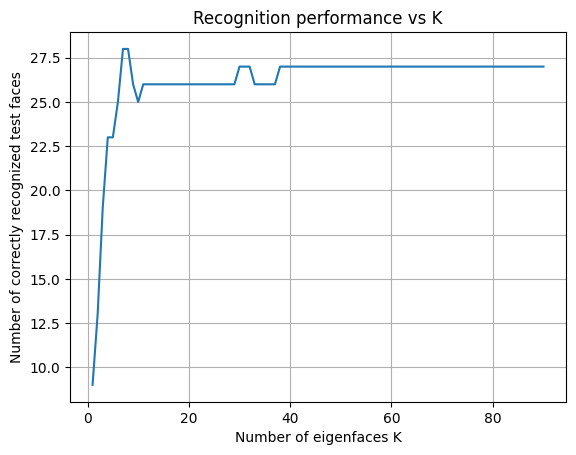

for K= 5 -> 23/30 correct
for K=10 -> 25/30 correct
for K=20 -> 26/30 correct
for K=30 -> 27/30 correct
for K=40 -> 27/30 correct
for K=50 -> 27/30 correct
for K=60 -> 27/30 correct
for K=90 -> 27/30 correct


In [67]:
#at first needs to center train and test faces for projection
Xc_train = centeredFaces(X_train)
Xc_test  = centeredFaces(X_test)
# for K = 30
K = 30
D = calculMatDist(Xc_train, Xc_test, U, K)
id_test_hat = identification(D, id_train)

nb_correct = np.sum(id_test_hat == id_test)
rate = nb_correct / len(id_test) * 100

print(f"for K={K}: {nb_correct}/{len(id_test)} correctly recognized: {rate:.2f}%")

#for different K and plotting number of recognized faces 
K_list = list(range(1, 91))   
nb_recognized = []

for K in K_list:
    D = calculMatDist(Xc_train, Xc_test, U, K)
    id_test_hat = identification(D, id_train)
    nb_correct = np.sum(id_test_hat == id_test)
    nb_recognized.append(nb_correct)

plt.figure()
plt.plot(K_list, nb_recognized)
plt.xlabel("Number of eigenfaces K")
plt.ylabel("Number of correctly recognized test faces")
plt.title("Recognition performance vs K")
plt.grid(True)
plt.show()

#now i wanted to see some values
for K in [5, 10, 20, 30, 40, 50, 60, 90]:
    D = calculMatDist(Xc_train, Xc_test, U, K)
    id_test_hat = identification(D, id_train)
    nb_correct = np.sum(id_test_hat == id_test)
    print(f"for K={K:2d} -> {nb_correct}/30 correct")


I have ploted curve and the printed results. I see when K is small the recognition performance is low. this is because only a few eigenfaces are used and important facial information is missing like 23/30 correct for K=5. But when K increased the number of correctly recognized faces increased like 25/30 for K=10 and 26/30 for K=20. and when K=30 the performance reaches 27/30 whic is 90% and then stays almost same for larger values of K. thats why i think K close or equal to 30 is best because it gives good recognition accuracy but keep the computation time less. I mean its better than using all 90 eigenfaces.

5.  **Bonus question**: for $K=30$, calculate for each face of the training set its distance in the subspace $\mathbf W_K$ from each element of the training set. Display the result as the image of a matrix. Comment the result.

6. **Bonus question**: What are the minimal and maximal distances between two faces of the same category (i.e. same person)? Between two faces of different categories? If we want to choose a threshold $\theta$  to detect the presence of an unknown face, which indications do the previous min/max values give us?

# Exercise 5: face/non-face classification

Until now, we focused on comparing facial images with each other. However, the method provides information that we have not yet used. In particular, the reconstruction error can be used to verify that an image is indeed an image of a face. When an image contains something other than a face (an image of a flower, a person seen in its entirety, a random image...), we can say that it is a non-face (database *noface*).

![figure8](./figs/Figure_8.png)
<center>Figure 8: Illustration of possible cases for classifying an image: case 1,2) $Z$ close to subspace: it is a face 3,4) $Z$ far from subspace: it is not a face, 1) $Z$ is an identified face, case 2) $z$ is an unknown face, case 3) risk of identifying $Z$ as a face when it is not.

1.  With $K=30$, for each set, training set, test set, and *noface* set, plot the reconstruction error of all the images of each set (this provides 3 plots). Compute the minimal, average, maximal errors for the three sets. Which conclusion can be drawn?

Training set:
min = 536.4401161364842
mean = 811.9744510277385
max = 1080.7572997669563

Test set:
min = 597.8763696370302
mean = 1182.3630522686547
max = 1689.796331922761

NoFace set:
min = 1984.8302725906358
mean = 3519.3049355664234
max = 4882.099590924443



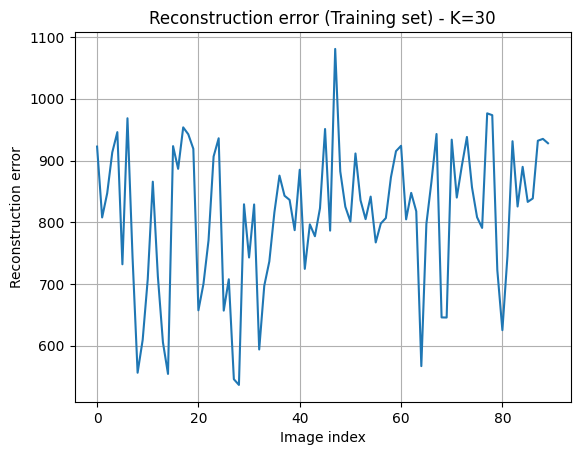

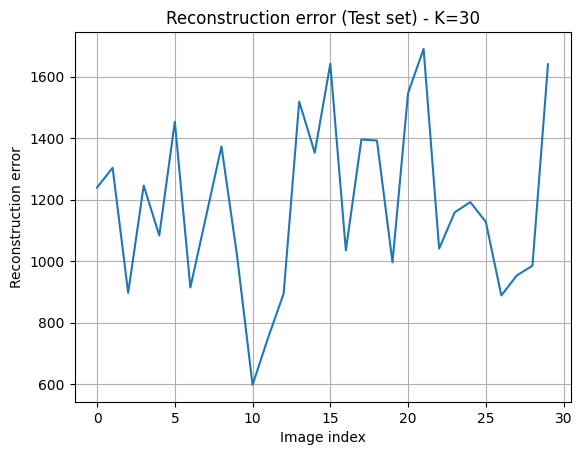

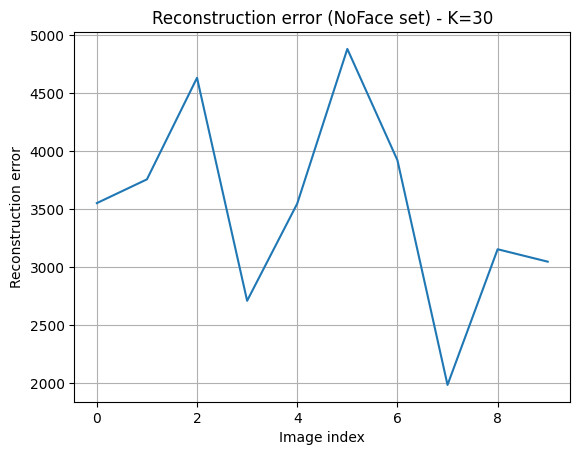

In [71]:
# given
K = 30

# same things like previous exercise
Xc_train = centeredFaces(X_train)
Xc_test  = centeredFaces(X_test)
Xc_noface = X_noface - x_mean[:, np.newaxis]

# writing a function that will compute reconstruction errors for all images in one set
def compute_errors(Xc_set, set_name):
    errors = []
    for i in range(Xc_set.shape[1]):
        x = Xc_set[:, i]
        z = projEigenface(x, np.zeros_like(x_mean), U, K)  
        x_rec = reconstruct(z, np.zeros_like(x_mean), U, K)
        errors.append(errorReconstruct(x_rec, x))
    errors = np.array(errors)

    print(f"{set_name} set:")
    print("min =", errors.min())
    print("mean =", errors.mean())
    print("max =", errors.max())
    print()

    return errors

#now need to compute errors for each set
err_train = compute_errors(Xc_train, "Training")
err_test  = compute_errors(Xc_test, "Test")
err_noface = compute_errors(Xc_noface, "NoFace")

#visualizing
plt.figure()
plt.plot(err_train)
plt.title(f"Reconstruction error (Training set) - K={K}")
plt.xlabel("Image index")
plt.ylabel("Reconstruction error")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(err_test)
plt.title(f"Reconstruction error (Test set) - K={K}")
plt.xlabel("Image index")
plt.ylabel("Reconstruction error")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(err_noface)
plt.title(f"Reconstruction error (NoFace set) - K={K}")
plt.xlabel("Image index")
plt.ylabel("Reconstruction error")
plt.grid(True)
plt.show()


From the results adn graph I can clearly see that faces and non faces are very differently in terms of reconstruction error. The training faces have the lowest errors because they were used to build the eigenface space. so they are reconstructed very well. The test faces have higher errors than training faces but they are still much smaller than the noface errors which means they are still close to the face subspace. but the noface images have very large reconstruction errors and i got much higher min, mean and max. This shows that images that are not faces cannot be well reconstructed using eigenfaces. so when low error it's likely a face but when high error it's likely not a face.

2. Visualize the reconstruction error by displaying the original image and the reconstructed image for 10 images of the face database, and for the 10 images of the noface database. Comment the results.

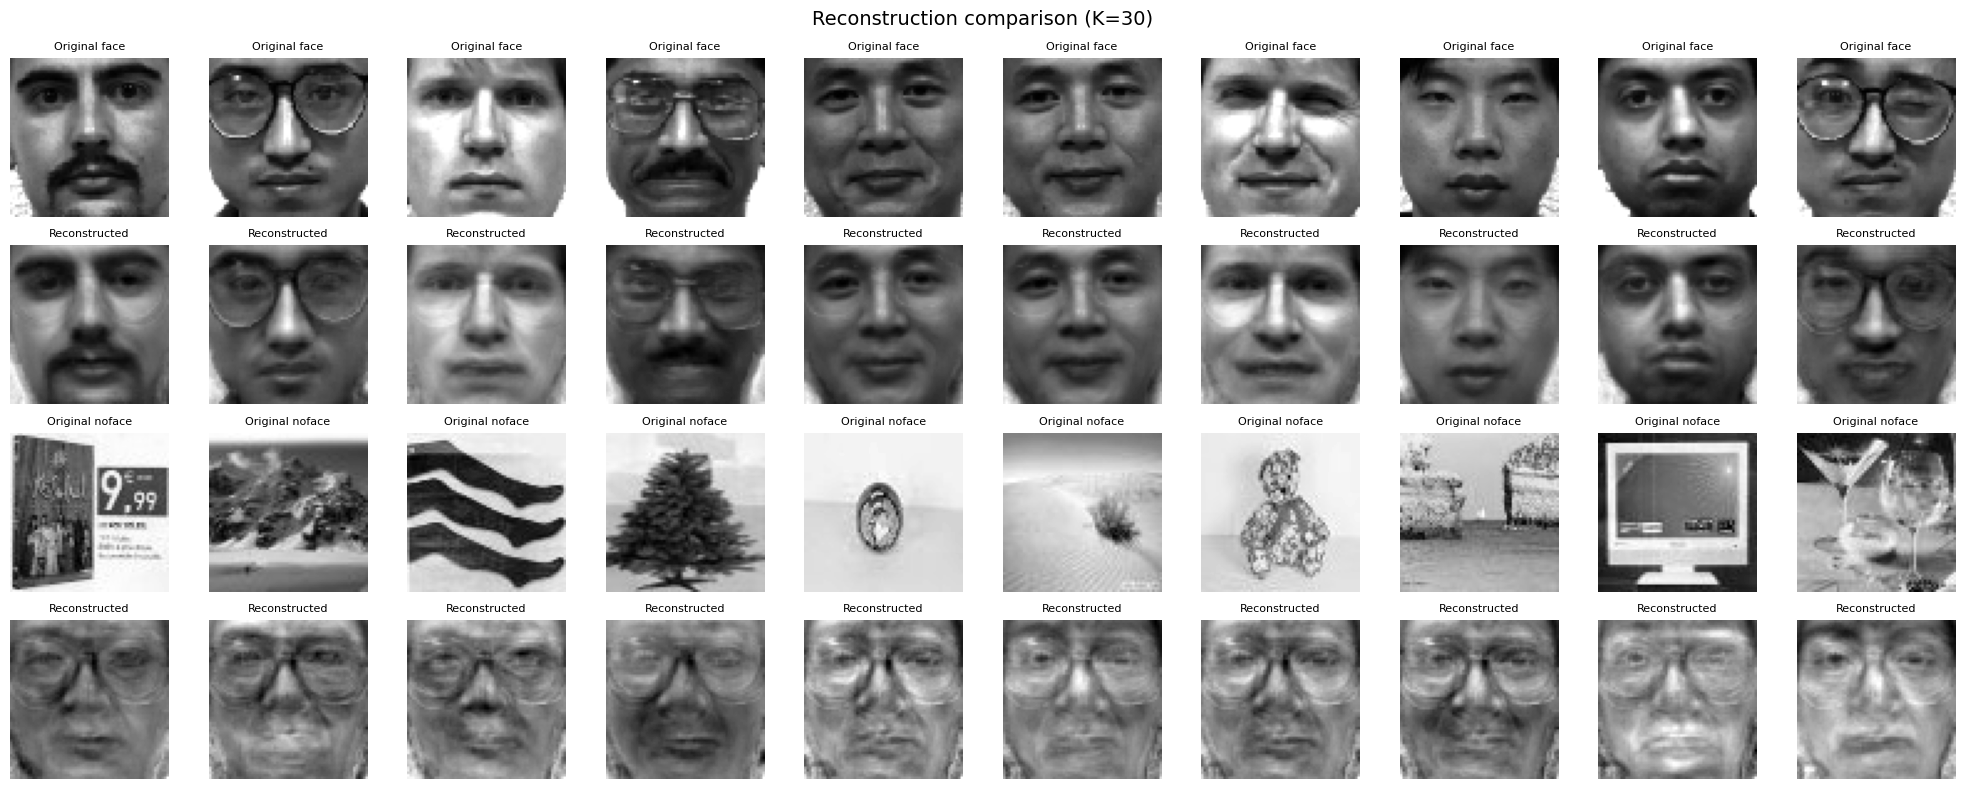

In [72]:
#using random like before

# writing a function to visualize original and reconstructed images for faces and nofaces
def visualize_faces_vs_nofaces(X_faces, X_noface, x_mean, W, K, title_faces, title_nofaces):
    fig, axes = plt.subplots(4, 10, figsize=(20, 8))
    idx_faces = random.sample(range(X_faces.shape[1]), 10)
    for i, idx in enumerate(idx_faces):
        x = X_faces[:, idx]
        z = projEigenface(x, x_mean, W, K)
        x_r = reconstruct(z, x_mean, W, K)
        
        axes[0, i].imshow(deflat(x), cmap='gray')
        axes[0, i].set_title("Original face", fontsize=8)
        axes[0, i].axis('off')
        
        axes[1, i].imshow(deflat(x_r), cmap='gray')
        axes[1, i].set_title("Reconstructed", fontsize=8)
        axes[1, i].axis('off')

    idx_noface = random.sample(range(X_noface.shape[1]), 10)
    for i, idx in enumerate(idx_noface):
        x = X_noface[:, idx]
        z = projEigenface(x, x_mean, W, K)
        x_r = reconstruct(z, x_mean, W, K)
        
        axes[2, i].imshow(deflat(x), cmap='gray')
        axes[2, i].set_title("Original noface", fontsize=8)
        axes[2, i].axis('off')
        
        axes[3, i].imshow(deflat(x_r), cmap='gray')
        axes[3, i].set_title("Reconstructed", fontsize=8)
        axes[3, i].axis('off')

    plt.suptitle(f"Reconstruction comparison (K={K})", fontsize=14)
    plt.tight_layout()
    plt.show()


# tryig for K = 30
visualize_faces_vs_nofaces(
    X_test, X_noface, x_mean, U, K=30,
    title_faces="Faces", title_nofaces="NoFaces"
)


I have visualized the original and reconstructed images for face and noface images using K = 30. For the face images the reconstructed images look very similar to the originals. The main facial features such as the eyes, nose, mouth etc I can see clearly. but image is a bit smoother. this means that faces are well represented in the eigenface subspace. but for noface images the reconstructed images look very different from the originals. Most of them are reconstructed like blurred face like shapes that do not match the original objects at all. This is because because non face images do not belong to the face subspace i mean i used face subspace for non face image thats why. in the visualization the reconstruction error is low for face images and high for non face images. That means eigenfaces can be used to distinguish faces from non faces.